<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/tarefa5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 5 - Bioestatística

###Anna Clara Tonial 17097091
###Laura Tavares Paes 17097601
###Lavinia Ramos 17081100

In [18]:
import pandas as pd
df = pd.read_excel("Tarefa_Semana3.xlsx")
df

,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
0,1,0,1,1,2,6
1,1,0,1,2,1,8
2,1,0,1,3,0,0
3,1,0,1,4,1,0
4,1,0,1,5,2,0
...,...,...,...,...,...,...
115,6,3,4,1,0,0
116,6,3,4,2,2,16
117,6,3,4,3,2,22
118,6,3,4,4,2,0


# Boxplot da variável Brotos

In [19]:
Brotos_quartiles = df["Brotos"].quantile([0.25, 0.5, 0.75])
print("Quartiles for 'Brotos' variable:")
print(Brotos_quartiles)

Quartiles for 'Brotos' variable:
0.25    0.0
0.50    2.0
0.75    2.0
Name: Brotos, dtype: float64


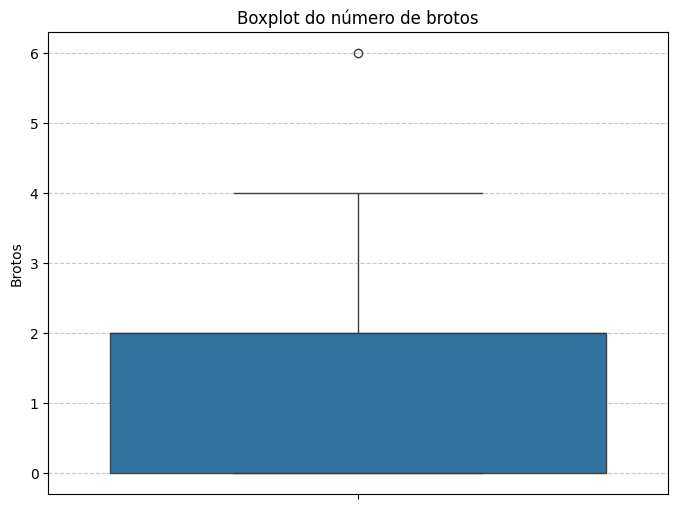

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Brotos'])
plt.title('Boxplot do número de brotos')
plt.ylabel('Brotos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

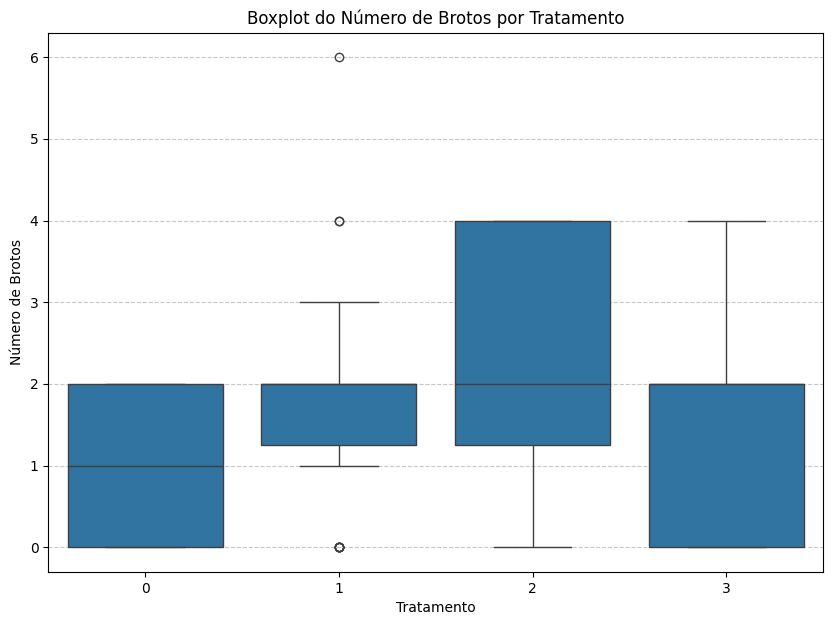

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.boxplot(x='Tratamento', y='Brotos', data=df)
plt.title('Boxplot do Número de Brotos por Tratamento')
plt.xlabel('Tratamento')
plt.ylabel('Número de Brotos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Boxplot da variável Folhas

In [20]:
Folhas_quartiles = df["Folhas"].quantile([0.25, 0.5, 0.75])
print("Quartiles for Folhas' variable:")
print(Folhas_quartiles)

Quartiles for Folhas' variable:
0.25     0.0
0.50    10.0
0.75    18.0
Name: Folhas, dtype: float64


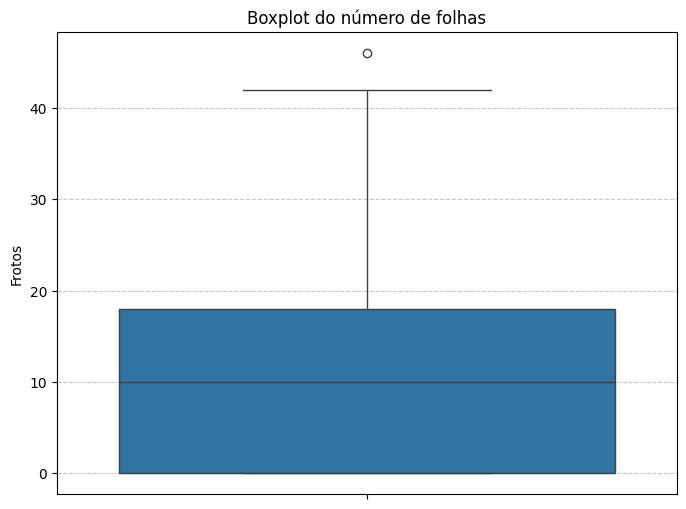

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Folhas'])
plt.title('Boxplot do número de folhas')
plt.ylabel('Frotos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Valores mínimos e máximos

In [27]:
print('Valores mínimos para Brotos e Folhas:\n', df[['Brotos', 'Folhas']].min())
print('\nValores máximos para Brotos e Folhas:\n', df[['Brotos', 'Folhas']].max())

Valores mínimos para Brotos e Folhas:
 Brotos    0
Folhas    0
dtype: int64

Valores máximos para Brotos e Folhas:
 Brotos     6
Folhas    46
dtype: int64


#Cálculos

In [28]:
media_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].mean()
display(media_por_tratamento)

,Brotos,Folhas
Tratamento,,
0,0.933333,5.400000
1,1.866667,15.000000
2,2.266667,11.700000
3,1.700000,9.066667


In [29]:
estatisticas_por_tratamento = df.groupby('Tratamento')[['Brotos', 'Folhas']].agg(['min', 'max', 'var', 'std'])

estatisticas_por_tratamento['Brotos', 'amplitude'] = estatisticas_por_tratamento['Brotos']['max'] - estatisticas_por_tratamento['Brotos']['min']
estatisticas_por_tratamento['Folhas', 'amplitude'] = estatisticas_por_tratamento['Folhas']['max'] - estatisticas_por_tratamento['Folhas']['min']

estatisticas_por_tratamento = estatisticas_por_tratamento.reindex(columns=pd.MultiIndex.from_product([['Brotos', 'Folhas'], ['amplitude', 'var', 'std']]))

display(estatisticas_por_tratamento)

Brotos                        Folhas                       
           amplitude       var       std amplitude         var        std
Tratamento                                                               
0                  2  0.685057  0.827682        20   40.593103   6.371272
1                  6  1.774713  1.332183        42  123.793103  11.126235
2                  4  2.271264  1.507071        32   82.148276   9.063569
3                  4  2.148276  1.465700        46  123.857471  11.129127

In [30]:

cv_por_tratamento = pd.DataFrame(index=media_por_tratamento.index)

cv_por_tratamento['Brotos_CV'] = (estatisticas_por_tratamento['Brotos']['std'] / media_por_tratamento['Brotos']) * 100
cv_por_tratamento['Folhas_CV'] = (estatisticas_por_tratamento['Folhas']['std'] / media_por_tratamento['Folhas']) * 100

display(cv_por_tratamento)

,Brotos_CV,Folhas_CV
Tratamento,,
0,88.680213,117.986514
1,71.366969,74.174899
2,66.488447,77.466398
3,86.217634,122.747726


#Perguntas

###1. Sim, existem observações atipícas para ambas variáveis, mas apenas uma ocorrência para cada. O valor mínimo para brotos é "0", enquanto o máximo é de "6"; o valor mínimo para folhas é de "0", enquanto o máximo é de "46". A variável folha representa a quantidade de folhas de segmento nodal que surgiram por explante após cada tratamento e a variável brotos traduz quantos brotos surgiram em cada explante após cada tratamento com BAP.

###2. Os quartis 2 e 3 da variável "brotos' são ambos iguais a 2, enquanto para a variável "folhas" são iguais a 10 e 18, respectivamente. O segundo quartil representa a mediana dos dados e separa os números em dois grandes blocos: os 50% menores que a mediana e os 50% maiores que a mediana. O terceiro quartil separa os dados em os 75% menores e os 25% maiores das observações.

###3. A média de brotos para as concentrações 0.0, 1.0, 2.0 e 3.0 mg/litro de BAP são, respectivamente, 0,93, 1,86, 2,26 e 1,70, enquanto para a variável folhas foi de 5,40, 15, 11,7, 9,06, respectivamente.

###4. Aparentemente, os tratamentos na concentração 1.0 e 2.0 mg/litro de BAP possuem maior variabilidade por aumentar os brotos em 2mg/litro e aumentar bastante as folhas em 1mg/litro e em menor média em concentração de 2mg/litro.

###5. Sim, existe diferença entre o controle e cada uma das doses de BAP observando as médias, já que o controle é a ocasião com menor brotação de brotos e indução de folhas, enquanto os tratamentos de 1mg/litro e 2mg/litro apresentaram aumentos significativos no número de brotos e folhas.

###6. A concentração de 1mg/litro apresenta maior número de folhas enquanto o controle mostra menor número de folhas.

###7. Observando as médias, não ocorre esta diferença acentuada, pois o tratamento com maior brotação foi o de concentração 2mg/litro, mas o número de folhas registrado é o segundo maior entre os 4 tratamentos. Em unidades experimentais, no entanto, esta situação acontece em todos os tratamentos.

###8. Os cálculos estão registrados acima. Os tratamentos 2 e 3 apresentam maior variabilidade para a variável brotos, pois apresentam maior variância e desvio-padrão. Já para folhas, os tratamentos 1 e 3 mostraram maior variabilidade por possuirem maior variância e desvio-padrão.

###9. Calculados registrados acima.

###10. Boxplot registrado acima. Observa-se que a mediana nos tratamentos 1 e 3 possui mesmo valor que terceiro quartil, provavelmente indicando uma moda (repetição de valores). O tratamento 1 mostrou distribuição mais concentrada de valores, sendo o único tratamento com ocorrência de valores atípicos. Além disso, nota-se que os tratamentos 2 e 3 possuem maior área de dispersão (limites definidos em área igual), mas o tratamento 2 se difere por apresenta mediana de valor diferente do terceiro quartil, possuindo maior dispersão de valores acima do valor da mediana.

###11. Como dito na questão anterior, o tratamento 1 mostrou maior concentração de dados, enquanto 2 e 3 apresentou maior dispersão, com destaque para 2 pela mediana demarcada diferente do valor do terceiro quartil.